# Deck Type EDA

A deck type is defined by its complete sorted list of 60 card IDs. Deck IDs are assigned by total usage: ID 1 is the most-used deck. All displayed deck-level results require more than 100 uses.

In [37]:
from pathlib import Path
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA = Path('../data/decks')
MIN_DISPLAY_USES = 200

files = sorted(DATA.glob('*.decks.csv'))
assert files, f'No deck cache found at: {DATA.resolve()}'
decks = pd.concat(
    (pd.read_csv(path, dtype={'date': str, 'episode_id': str}) for path in files),
    ignore_index=True,
)
required = {'date', 'episode_id', 'player', 'deck', 'reward', 'result'}
missing = required - set(decks.columns)
assert not missing, f'Outdated cache; missing columns: {missing}. Run deck.extract again.'
decks.head()

,date,episode_id,player,deck,reward,result
0,7.10,85109456,0,"[5,5,13,19,19,19,19,66,66,140,305,305,305,343,...",-1.0,loss
1,7.10,85109456,1,"[5,5,5,19,19,19,19,66,66,66,140,305,305,305,30...",1.0,win
2,7.10,85109552,0,"[1,11,11,11,11,14,14,14,14,18,18,18,18,343,344...",1.0,win
3,7.10,85109552,1,"[5,5,13,19,19,19,19,66,66,140,305,305,305,343,...",-1.0,loss
4,7.10,85109566,0,"[1,11,11,11,11,14,14,14,14,18,18,18,18,343,344...",-1.0,loss


## Build usage-ranked deck IDs

Usage ties are resolved deterministically by the complete card tuple. IDs will change when the input dataset changes because they represent the ranking for the currently loaded data.

In [38]:
def canonical_deck(value):
    cards = ast.literal_eval(value) if isinstance(value, str) else value
    cards = tuple(sorted(map(int, cards)))
    if len(cards) != 60:
        raise ValueError(f'Deck does not contain 60 cards: {len(cards)}')
    return cards

decks['deck_cards'] = decks['deck'].map(canonical_deck)
decks['is_win'] = decks['result'].eq('win')
decks['is_loss'] = decks['result'].eq('loss')
decks['is_draw'] = decks['result'].eq('draw')

deck_stats = (decks.groupby('deck_cards', as_index=False)
    .agg(uses=('deck_cards', 'size'),
         wins=('is_win', 'sum'),
         losses=('is_loss', 'sum'),
         draws=('is_draw', 'sum'),
         first_date=('date', 'min'),
         last_date=('date', 'max')))
deck_stats['decided_games'] = deck_stats['wins'] + deck_stats['losses']
deck_stats['win_rate'] = (deck_stats['wins'] / deck_stats['decided_games']).where(deck_stats['decided_games'].gt(0))
deck_stats['usage_share'] = deck_stats['uses'] / deck_stats['uses'].sum()
deck_stats = deck_stats.sort_values(['uses', 'deck_cards'], ascending=[False, True]).reset_index(drop=True)
deck_stats.insert(0, 'deck_id', range(1, len(deck_stats) + 1))
decks['deck_id'] = decks['deck_cards'].map(deck_stats.set_index('deck_cards')['deck_id'])
eligible = deck_stats.query('uses > @MIN_DISPLAY_USES').copy()

print(f'Matches: {decks.episode_id.nunique():,}')
print(f'Deck usages: {len(decks):,}')
print(f'Unique deck types: {len(deck_stats):,}')
print(f'Deck types with more than {MIN_DISPLAY_USES} uses: {len(eligible):,}')

Matches: 65,783
Deck usages: 131,566
Unique deck types: 483
Deck types with more than 200 uses: 107


## Deck usage ranking

In [39]:
usage_columns = ['deck_id', 'uses', 'usage_share', 'wins', 'losses', 'draws', 'win_rate', 'first_date', 'last_date']
display(eligible[usage_columns].head(30).style.format({
    'usage_share': '{:.2%}', 'win_rate': '{:.1%}'
}))

,deck_id,uses,usage_share,wins,losses,draws,win_rate,first_date,last_date
0,1,12288,9.34%,6211,6047,30,50.7%,7.10,7.9
1,2,9293,7.06%,4815,4461,17,51.9%,7.10,7.9
2,3,6561,4.99%,3116,3441,4,47.5%,7.10,7.9
3,4,6365,4.84%,3362,3001,2,52.8%,7.10,7.9
4,5,5144,3.91%,2756,2383,5,53.6%,7.10,7.9
5,6,5028,3.82%,2770,2249,9,55.2%,7.10,7.15
6,7,4811,3.66%,2642,2169,0,54.9%,7.10,7.9
7,8,3338,2.54%,1778,1560,0,53.3%,7.10,7.9
8,9,3197,2.43%,1647,1549,1,51.5%,7.10,7.9
9,10,3077,2.34%,1545,1532,0,50.2%,7.10,7.9


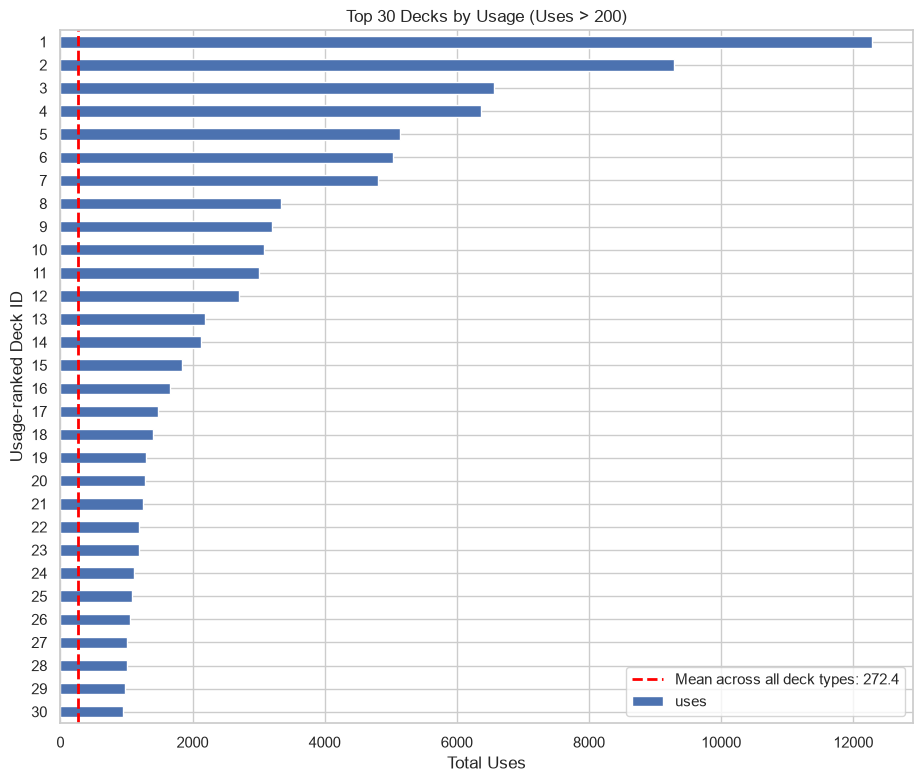

In [40]:
top_usage = eligible.head(30).sort_values('uses')
mean_uses = deck_stats['uses'].mean()
ax = top_usage.plot.barh(x='deck_id', y='uses', figsize=(11, 9), legend=False)
ax.axvline(mean_uses, color='red', linestyle='--', linewidth=2, label=f'Mean across all deck types: {mean_uses:.1f}')
ax.set(title=f'Top 30 Decks by Usage (Uses > {MIN_DISPLAY_USES})', xlabel='Total Uses', ylabel='Usage-ranked Deck ID')
ax.legend();

## Deck win rates

The left chart maps each usage-ranked deck ID to its overall win rate. The right chart retains the usage-versus-win-rate view.

,deck_id,uses,usage_share,wins,losses,draws,win_rate,first_date,last_date
94,95,235,0.18%,143,92,0,60.9%,7.7,7.8
21,22,1193,0.91%,706,487,0,59.2%,7.10,7.15
86,87,272,0.21%,159,113,0,58.5%,7.5,7.7
31,32,907,0.69%,517,390,0,57.0%,7.10,7.9
28,29,980,0.74%,555,425,0,56.6%,7.5,7.9
46,47,559,0.42%,316,243,0,56.5%,7.11,7.15
43,44,598,0.45%,337,261,0,56.4%,7.14,7.15
76,77,313,0.24%,176,137,0,56.2%,7.14,7.15
56,57,424,0.32%,236,185,3,56.1%,7.15,7.15
96,97,226,0.17%,126,100,0,55.8%,7.3,7.3


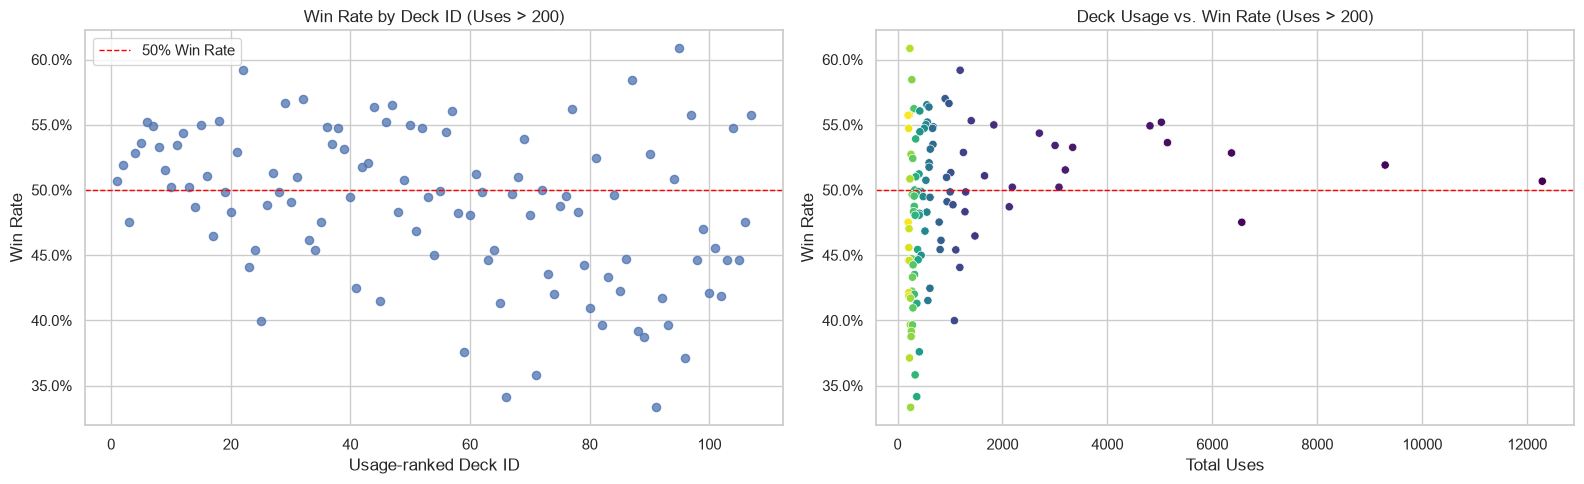

In [41]:
win_rate_ranking = (eligible.query('decided_games > 0')
    .sort_values(['win_rate', 'uses'], ascending=[False, False]))
display(win_rate_ranking[usage_columns].head(30).style.format({
    'usage_share': '{:.2%}', 'win_rate': '{:.1%}'
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
id_win_rates = win_rate_ranking.sort_values('deck_id')
axes[0].scatter(id_win_rates['deck_id'], id_win_rates['win_rate'], alpha=.75, s=35)
axes[0].axhline(.5, color='red', linestyle='--', linewidth=1, label='50% Win Rate')
axes[0].set(title=f'Win Rate by Deck ID (Uses > {MIN_DISPLAY_USES})', xlabel='Usage-ranked Deck ID', ylabel='Win Rate')
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend()

sns.scatterplot(data=win_rate_ranking, x='uses', y='win_rate', hue='deck_id', palette='viridis', legend=False, ax=axes[1])
axes[1].axhline(.5, color='red', linestyle='--', linewidth=1)
axes[1].set(title=f'Deck Usage vs. Win Rate (Uses > {MIN_DISPLAY_USES})', xlabel='Total Uses', ylabel='Win Rate')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout();

## Deck trends

The four charts compare the top 10 eligible decks by total usage and the top 10 eligible decks by overall win rate. Daily win rate is calculated from decided games on that date.

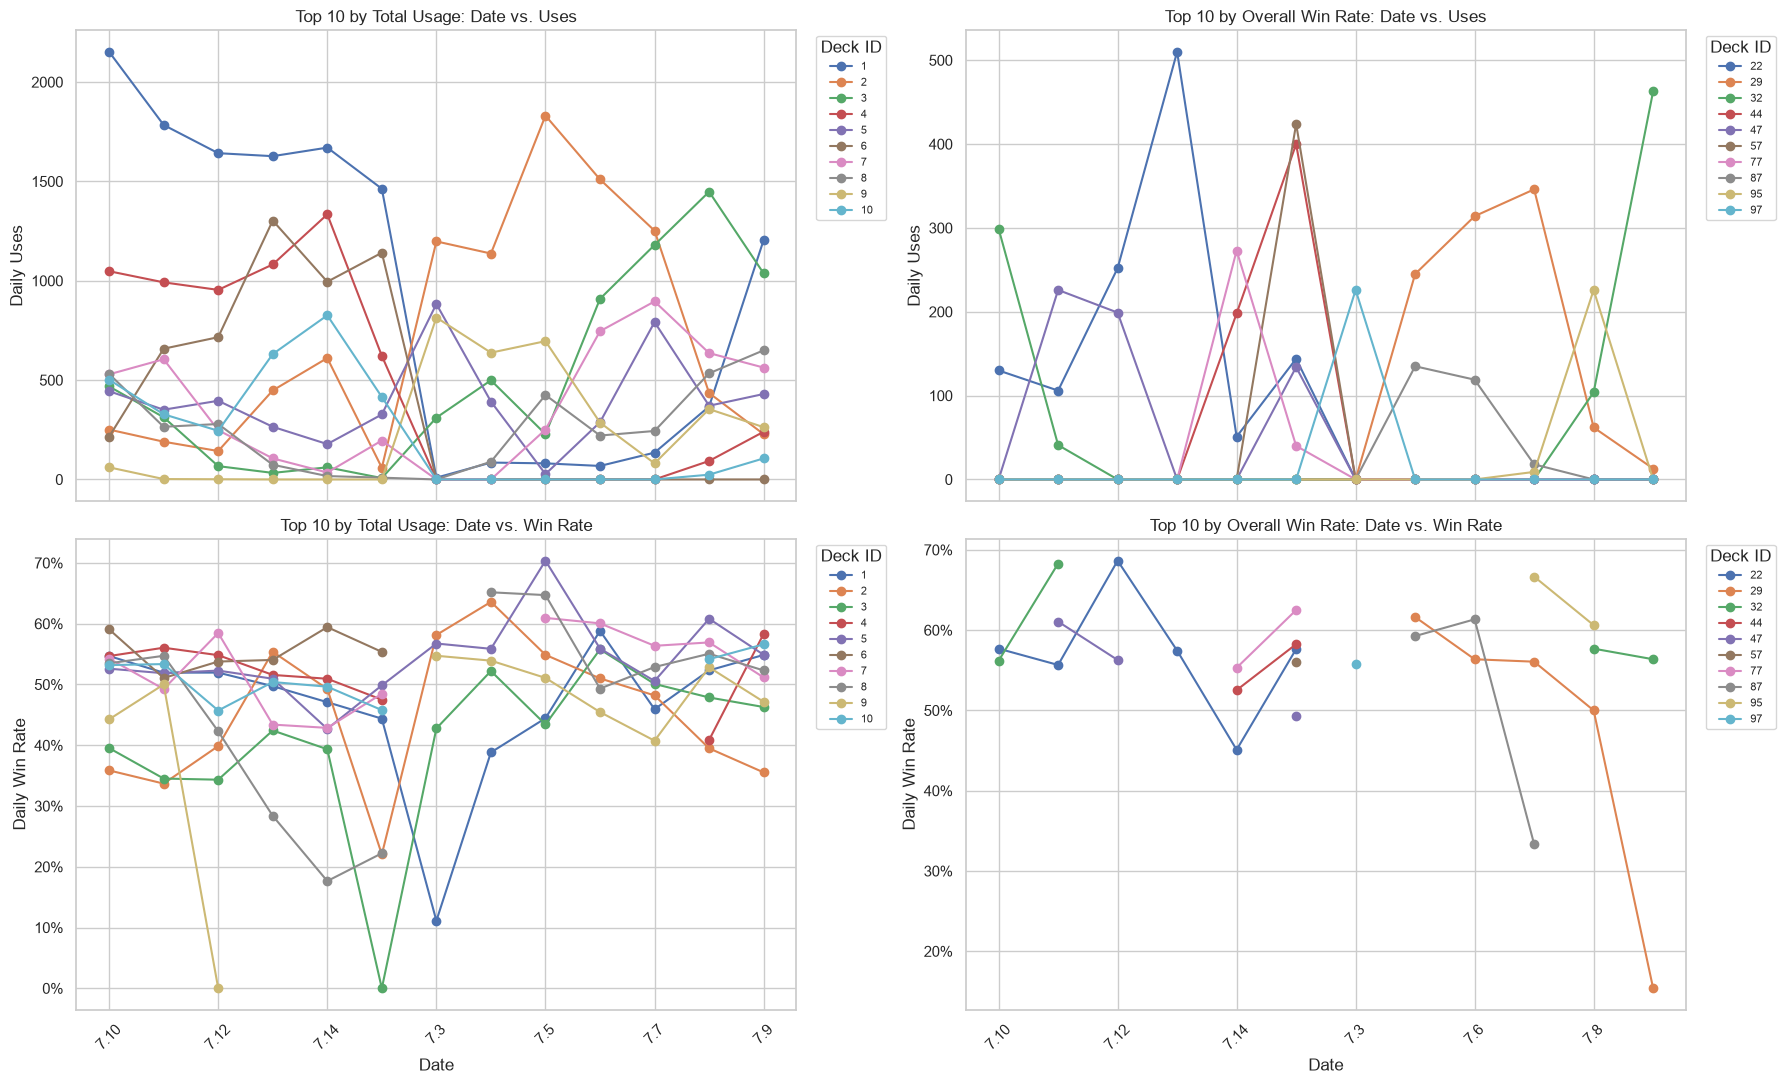

In [44]:
def daily_metrics(deck_ids):
    daily = (decks[decks['deck_id'].isin(deck_ids)]
        .groupby(['date', 'deck_id'], as_index=False)
        .agg(uses=('deck_id', 'size'), wins=('is_win', 'sum'), losses=('is_loss', 'sum')))
    decided = daily['wins'] + daily['losses']
    daily['win_rate'] = (daily['wins'] / decided).where(decided.gt(0))
    return daily

top_usage_ids = eligible.nlargest(10, 'uses')['deck_id'].tolist()
top_win_rate_ids = win_rate_ranking.nlargest(10, 'win_rate')['deck_id'].tolist()
daily_usage_leaders = daily_metrics(top_usage_ids)
daily_win_rate_leaders = daily_metrics(top_win_rate_ids)

fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharex='col')

daily_usage_leaders.pivot(index='date', columns='deck_id', values='uses').fillna(0).plot(
    ax=axes[0, 0], marker='o', title='Top 10 by Total Usage: Date vs. Uses')
daily_usage_leaders.pivot(index='date', columns='deck_id', values='win_rate').plot(
    ax=axes[1, 0], marker='o', title='Top 10 by Total Usage: Date vs. Win Rate')
daily_win_rate_leaders.pivot(index='date', columns='deck_id', values='uses').fillna(0).plot(
    ax=axes[0, 1], marker='o', title='Top 10 by Overall Win Rate: Date vs. Uses')
daily_win_rate_leaders.pivot(index='date', columns='deck_id', values='win_rate').plot(
    ax=axes[1, 1], marker='o', title='Top 10 by Overall Win Rate: Date vs. Win Rate')

for ax in axes[0]:
    ax.set_ylabel('Daily Uses')
for ax in axes[1]:
    ax.set_ylabel('Daily Win Rate')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Deck ID', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()

## Look up the complete card list for a deck ID

In [45]:
DECK_ID = 1  # Change this integer to inspect another usage-ranked deck.

match = deck_stats.loc[deck_stats['deck_id'].eq(DECK_ID)]
if match.empty:
    raise KeyError(f'Deck ID {DECK_ID} does not exist. Valid range: 1..{len(deck_stats)}')
row = match.iloc[0]
card_list = list(row['deck_cards'])
print(f'Deck ID: {DECK_ID}')
print(f'Usage rank: {DECK_ID}')
print(f'Uses: {row["uses"]:,}')
print(f'Win rate: {row["win_rate"]:.1%}')
print(f'Card list ({len(card_list)} cards):')
card_list

Deck ID: 1
Usage rank: 1
Uses: 12,288
Win rate: 50.7%
Card list (60 cards):


[5,
 5,
 13,
 19,
 19,
 19,
 19,
 66,
 66,
 140,
 305,
 305,
 305,
 343,
 741,
 741,
 741,
 741,
 742,
 742,
 742,
 742,
 743,
 743,
 743,
 743,
 1079,
 1079,
 1079,
 1081,
 1081,
 1081,
 1086,
 1086,
 1086,
 1086,
 1097,
 1129,
 1152,
 1152,
 1152,
 1152,
 1182,
 1182,
 1182,
 1184,
 1197,
 1197,
 1197,
 1225,
 1225,
 1225,
 1225,
 1231,
 1231,
 1231,
 1231,
 1266,
 1266,
 1266]